In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [15]:
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [16]:
X, y = make_moons(100, noise=0.25,random_state=2)

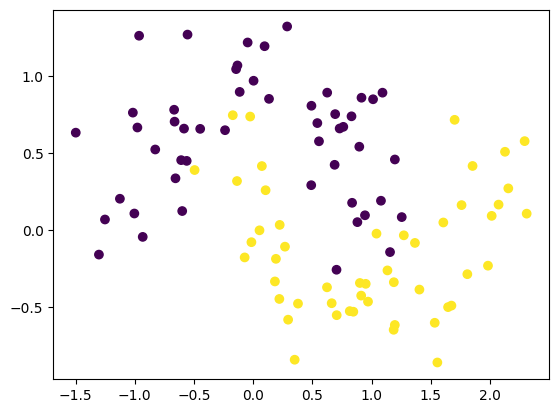

In [17]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [18]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.9375 - loss: 0.1908 - val_accuracy: 0.9500 - val_loss: 0.2355
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9375 - loss: 0.1031 - val_accuracy: 0.9000 - val_loss: 0.5765
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9375 - loss: 0.1826 - val_accuracy: 0.9500 - val_loss: 0.2713
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9625 - loss: 0.0872 - val_accuracy: 0.9500 - val_loss: 0.1569
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9375 - loss: 0.1089 - val_accuracy: 0.9500 - val_loss: 0.1274
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9500 - loss: 0.0862 - val_accuracy: 0.9500 - val_loss: 0.1808
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9750 - loss: 0.0806 - val_accuracy: 0.9000 - val_loss: 0.3282
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9750 - loss: 0.0888 - val_accuracy: 0.9000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


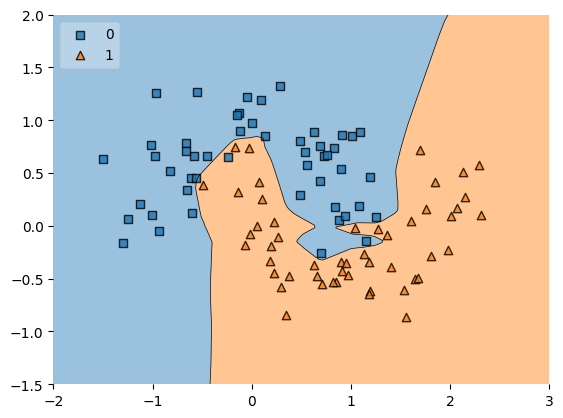

In [9]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

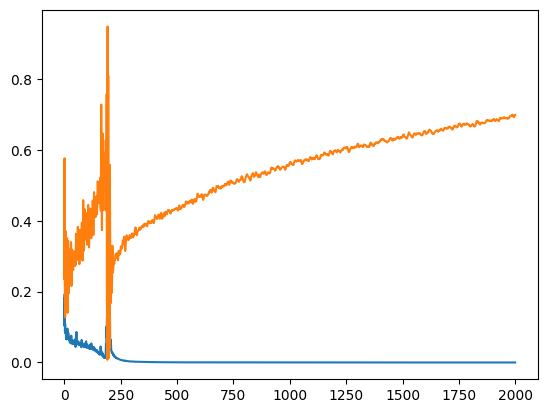

In [19]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

See we observe a different loss while training on 2,000 epochs. 2,000 epochs take a very long time. Now we are going to reduce the number of epochs and also we are going to add regularization (L2). We can also add L1 but adding L2 is more preferable in ANN models.

In [24]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2

model2=Sequential([
    Input(shape=(2,)),
    Dense(128,activation="relu",kernel_regularizer=l2(0.001)),
    Dense(128,activation="relu",kernel_regularizer=l2(0.001)),
    Dense(1,activation="sigmoid")
])

In [26]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=800, validation_split = 0.2)

Epoch 1/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.9000 - loss: 0.3402 - val_accuracy: 0.9500 - val_loss: 0.1280
Epoch 2/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9375 - loss: 0.1867 - val_accuracy: 0.9000 - val_loss: 0.2098
Epoch 3/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9375 - loss: 0.2185 - val_accuracy: 0.9500 - val_loss: 0.2263
Epoch 4/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9375 - loss: 0.1878 - val_accuracy: 0.9500 - val_loss: 0.1727
Epoch 5/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9375 - loss: 0.1743 - val_accuracy: 0.9500 - val_loss: 0.2505
Epoch 6/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9750 - loss: 0.1622 - val_accuracy: 0.9500 - val_loss: 0.1962
Epoch 7/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9625 - loss: 0.1407 - val_accuracy: 0.9500 - val_loss: 0.1639
Epoch 8/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9375 - loss: 0.1614 - val_accuracy: 0.9500 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


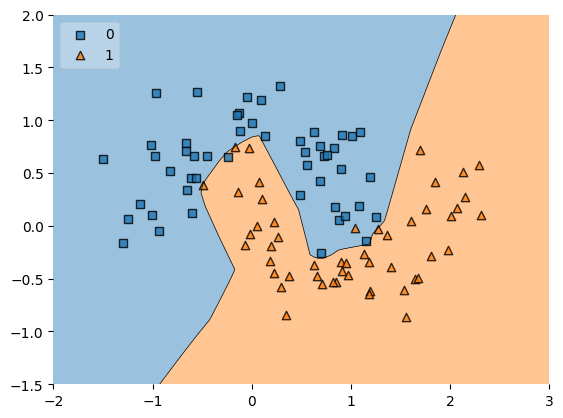

In [27]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

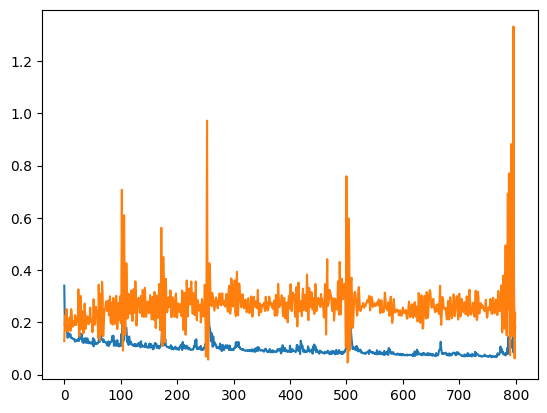

In [28]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

See we got a much better model than the previous one in just 800 epochs. Now we are going to show you how my previous model and my current model are different in terms of weights. You will see my first model is more spread out toward all the integer values rather than zero and my second model is more skewed towards zero. That's because of the regularization.

In [29]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

In [30]:
import seaborn as sns

<Axes: >

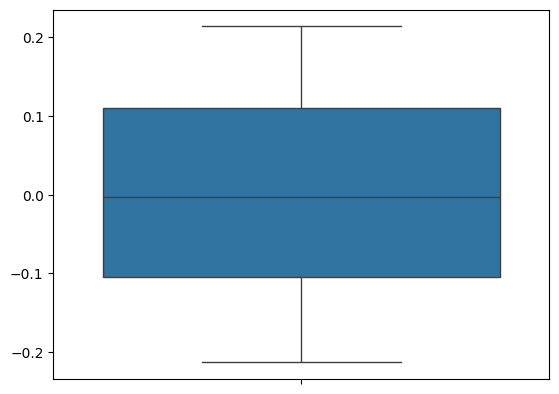

In [31]:
sns.boxplot(model1_weight_layer1)

<Axes: >

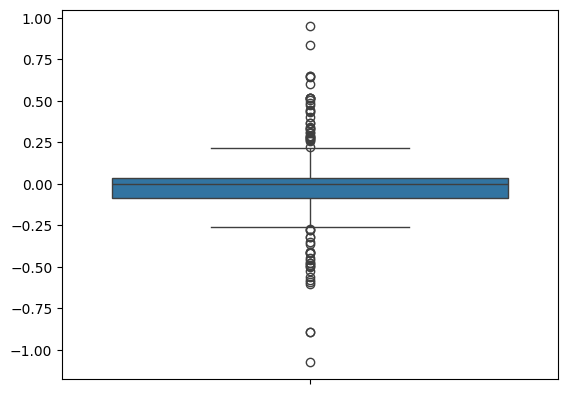

In [32]:
sns.boxplot(model2_weight_layer1)

/tmp/ipykernel_735/2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
/tmp/ipykernel_735/2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

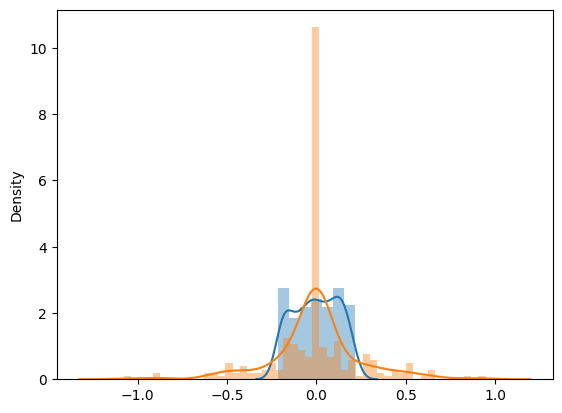

In [33]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

The blue line shows the convergence or the range of model 1, which is more towards other numbers also, while the orange one is the regularization model 2, where the weights are more towards zero.